# How `direction_id` assignment and stop headway ("mean interval") actually work

This notebook walks through the internals of two mechanisms in
`pyGTFSHandler`, with small synthetic examples and plots:

1. **`direction_id` assignment** (`pyGTFSHandler/models/shapes.py`) -- how a
   shape's forward/backward bearings through a stop get reconciled into one
   consistent 0/1 label per route, and how that reconciliation is
   propagated across a whole route's stops.
2. **Headway ("mean interval") at stops** (`pyGTFSHandler/analysis/stops.py`)
   -- the actual formula used to summarize a stop's departures into a
   single "typical interval" number, and why it isn't a plain average.


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np

from pyGTFSHandler.models.shapes import _reconcile_fwd_bwd, _widest_gap_split


## 1. Forcing forward/backward bearings to be exactly 180 degrees apart

At a stop a shape merely passes through, its incoming ("forward") bearing
and its outgoing ("backward") bearing *should* point in exactly opposite
directions -- 180 degrees apart. In practice the raw computed bearings
rarely land on exactly 180 degrees apart (different `shape_pt_sequence`
spacing before/after the stop, slightly curved segments, etc.), so
`_reconcile_fwd_bwd` corrects both readings *symmetrically*: it rotates the
forward bearing and the backward bearing toward each other by the same
magnitude, in opposite directions, until they're exactly 180 degrees apart.

Neither raw reading is trusted over the other -- the correction is split
50/50.


In [2]:
examples = [
    (30.0, 100.0),
    (270.0, 300.0),
]

for fwd, bwd in examples:
    corrected = _reconcile_fwd_bwd(fwd, bwd)
    fwd_final, bwd_final = corrected
    print(
        f"forward={fwd:6.1f}  backward={bwd:6.1f}   ->   "
        f"forward'={fwd_final:6.1f}  backward'={bwd_final:6.1f}   "
        f"(diff={((bwd_final - fwd_final) % 360):.1f}, "
        f"|Δforward|={abs(((fwd_final - fwd + 540) % 360) - 180):.1f}, "
        f"|Δbackward|={abs(((bwd_final - bwd + 540) % 360) - 180):.1f})"
    )


forward=  30.0  backward= 100.0   ->   forward'= 335.0  backward'= 155.0   (diff=180.0, |Δforward|=55.0, |Δbackward|=55.0)
forward= 270.0  backward= 300.0   ->   forward'= 195.0  backward'=  15.0   (diff=180.0, |Δforward|=75.0, |Δbackward|=75.0)


Both examples land on a corrected pair exactly 180 degrees apart, and the
rotation applied to `forward` has the same magnitude as the rotation
applied to `backward` (opposite sign) -- confirmed by the `|Δforward|` /
`|Δbackward|` columns above being equal.

Let's plot this: the raw forward/backward bearings (dashed, faded) versus
the corrected pair (solid), on a compass circle. 0° points up (north), and
angles increase clockwise, matching the bearing convention used
elsewhere in the codebase.


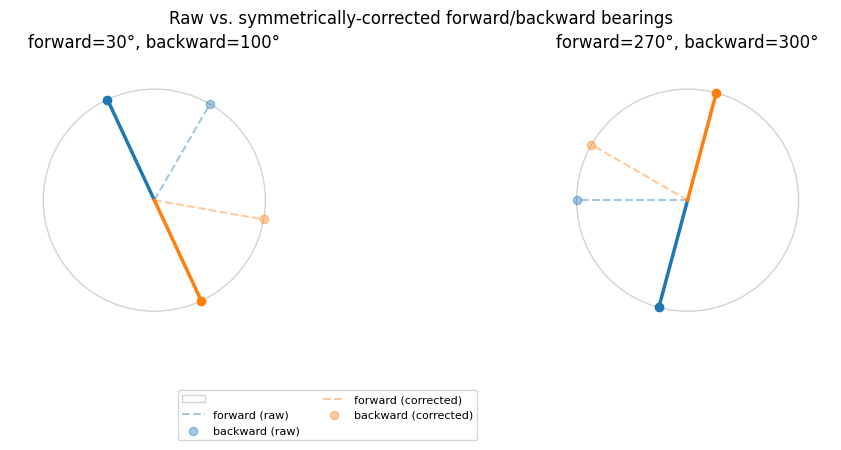

In [3]:
def bearing_to_xy(deg):
    rad = math.radians(deg)
    return math.sin(rad), math.cos(rad)


fig, axes = plt.subplots(1, len(examples), figsize=(9, 4.5), subplot_kw={"aspect": "equal"})

for ax, (fwd, bwd) in zip(axes, examples):
    fwd_final, bwd_final = _reconcile_fwd_bwd(fwd, bwd)

    circle = plt.Circle((0, 0), 1, fill=False, color="lightgray", linewidth=1)
    ax.add_patch(circle)

    for deg, color, label, style in [
        (fwd, "tab:blue", "forward (raw)", "dashed"),
        (bwd, "tab:orange", "backward (raw)", "dashed"),
        (fwd_final, "tab:blue", "forward (corrected)", "solid"),
        (bwd_final, "tab:orange", "backward (corrected)", "solid"),
    ]:
        x, y = bearing_to_xy(deg)
        alpha = 1.0 if style == "solid" else 0.4
        lw = 2.5 if style == "solid" else 1.5
        ax.plot([0, x], [0, y], color=color, linestyle=style, alpha=alpha, linewidth=lw)
        ax.scatter([x], [y], color=color, alpha=alpha, zorder=3)

    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_title(f"forward={fwd:.0f}°, backward={bwd:.0f}°")
    ax.axis("off")

axes[0].legend(
    ["", "forward (raw)", "backward (raw)", "forward (corrected)", "backward (corrected)"],
    loc="lower center", bbox_to_anchor=(1.1, -0.35), ncol=2, fontsize=8,
)
fig.suptitle("Raw vs. symmetrically-corrected forward/backward bearings")
plt.tight_layout()
plt.show()


## 2. Why each shape contributes two points to the split

Once every shape has bearings at a stop, `_widest_gap_split` clusters
those bearings into two local bins (0/1) by finding the single widest gap
between the observed bearings on the compass circle, and splitting the
circle at that gap's midpoint.

Each shape contributes **both** points of its corrected forward/backward
pair (`_reconcile_fwd_bwd`'s antipodal pair), not just one. This matters
because two shapes genuinely going the *same* way through a stop can still
have slightly different bearings (GPS/geometry noise) -- with only their
antipodal partners also in the mix, the far side of the circle is filled
in too, so a small gap between two near-duplicate bearings on one side is
never mistaken for the widest gap. Only a real gap between two genuinely
different direction clusters is.


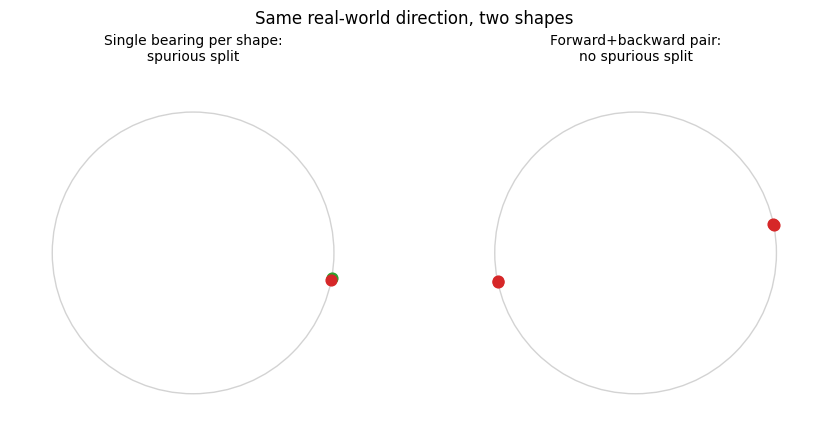

In [4]:
def plot_widest_gap(ax, bearings_by_shape, title):
    """bearings_by_shape: {shape_id: [angles]}"""
    bins = _widest_gap_split(bearings_by_shape)

    circle = plt.Circle((0, 0), 1, fill=False, color="lightgray", linewidth=1)
    ax.add_patch(circle)

    colors = {0: "tab:green", 1: "tab:red"}
    for shape_id, angles in bearings_by_shape.items():
        b = bins[shape_id]
        for deg in angles:
            x, y = bearing_to_xy(deg)
            ax.scatter([x], [y], color=colors[b], s=60, zorder=3)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_title(title, fontsize=10)
    ax.axis("off")


# Two shapes going almost exactly the SAME way through a stop -- forward
# bearings 0.8 degrees apart, as seen in a real feed (GPS/geometry noise,
# not a real direction split). Contrast a single bearing per shape with
# the forward/backward antipodal pair `_reconcile_fwd_bwd` produces.
same_direction_single_point = {
    "shape_a": [100.27],
    "shape_b": [101.09],
}
same_direction_with_backward = {
    "shape_a": _reconcile_fwd_bwd(100.27, 236.17),
    "shape_b": _reconcile_fwd_bwd(101.09, 236.17),
}

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), subplot_kw={"aspect": "equal"})
plot_widest_gap(axes[0], same_direction_single_point, "Single bearing per shape:\nspurious split")
plot_widest_gap(axes[1], same_direction_with_backward, "Forward+backward pair:\nno spurious split")
fig.suptitle("Same real-world direction, two shapes")
plt.tight_layout()
plt.show()


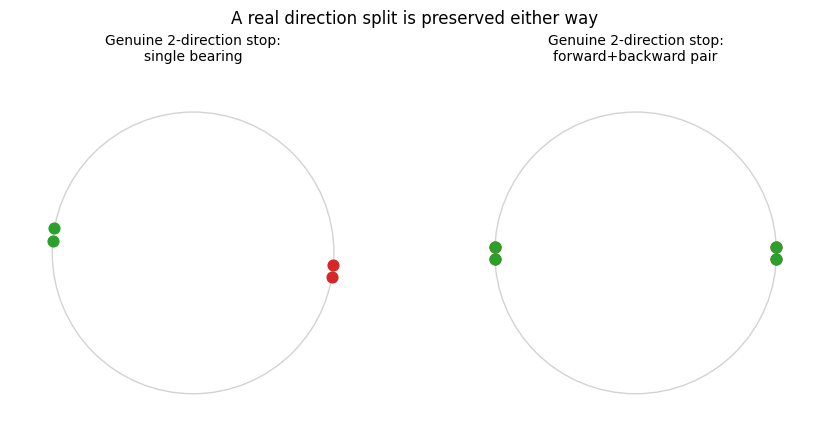

In [5]:
# A genuine two-direction stop (outbound vs inbound), for contrast: the
# widest-gap split correctly separates them either way, single-point or pair.
genuine_split_raw = {
    "outbound_a": [95.0],
    "outbound_b": [100.0],
    "inbound_a": [275.0],
    "inbound_b": [280.0],
}
genuine_split_with_backward = {
    "outbound_a": _reconcile_fwd_bwd(95.0, 260.0),
    "outbound_b": _reconcile_fwd_bwd(100.0, 265.0),
    "inbound_a": _reconcile_fwd_bwd(275.0, 80.0),
    "inbound_b": _reconcile_fwd_bwd(280.0, 85.0),
}

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5), subplot_kw={"aspect": "equal"})
plot_widest_gap(axes[0], genuine_split_raw, "Genuine 2-direction stop:\nsingle bearing")
plot_widest_gap(axes[1], genuine_split_with_backward, "Genuine 2-direction stop:\nforward+backward pair")
fig.suptitle("A real direction split is preserved either way")
plt.tight_layout()
plt.show()


## 3. From per-stop bins to a route-wide `direction_id`

A stop's 0/1 bin is only meaningful *at that one stop* -- nothing ties "0"
at one stop to "0" at another. `Shapes._assign_direction_ids_for_route`
reconciles this across a whole route by:

1. Picking the stop with the most distinct `shape_id`s as the **anchor**
   -- its labels become the route's canonical `direction_id`s.
2. Walking every other stop (fewest shapes first), and at each one
   choosing whichever of {keep local labels, flip them} agrees with more
   already-resolved shapes.
3. Any shape that still disagrees with the chosen orientation at a stop is
   forced to the majority value there, and flagged
   (`direction_id_issues=True`) -- a genuine branching ambiguity, not a
   bug.

See `examples/direction_issue_example.ipynb` for a worked example against
a small synthetic feed with a genuine branch, and
`examples/direction_split_headway_example.ipynb` for using
`direction_id`/`shape_direction` through the public `Feed` API.


## 4. Headway ("mean interval") at stops

`StopsMixin._get_headway_at_stops` (`pyGTFSHandler/analysis/stops.py`)
summarizes a stop's list of departure times within a `[start, end]` window
into one "headway" number. It is **not** a plain average of the gaps
between departures -- it's a *root-mean-square-style* statistic that
penalizes irregular spacing more than a plain average would.

For a stop with sorted departures $d_1 < d_2 < \dots < d_n$ within
$[\,\text{start}, \text{end}\,]$, define the wrap-around gap

$$
g_0 \;=\; (d_1 - \text{start}) + (\text{end} - d_n)
$$

and the interior gaps $g_i = d_i - d_{i-1}$ for $i = 2, \dots, n$. Then

$$
\text{headway} \;=\; \frac{g_0^2 \;+\; \displaystyle\sum_{i=2}^{n} g_i^2}{\text{end} - \text{start}}
$$

Two things worth noting:

- **Why the wrap-around gap $g_0$ is $(d_1 - \text{start}) + (\text{end} -
  d_n)$, not two separate terms**: a rider arriving at a uniformly random
  time within $[\text{start}, \text{end}]$ either waits for the first
  departure (if they arrive before $d_1$) or waits for the *next window's*
  first departure (if they arrive after $d_n$) -- both of those waits are
  bounded by this combined gap, so it's treated as a single gap of that
  length for the purposes of this statistic, same as any interior gap
  $g_i$.
- **Why squared, not just averaged**: squaring means a schedule with one
  large gap and several tiny ones scores *worse* than a perfectly uniform
  schedule with the same average gap -- exactly like RMS vs. mean. This
  matches the intuition that irregular service is worse for riders than
  the arithmetic mean of the gaps alone would suggest.


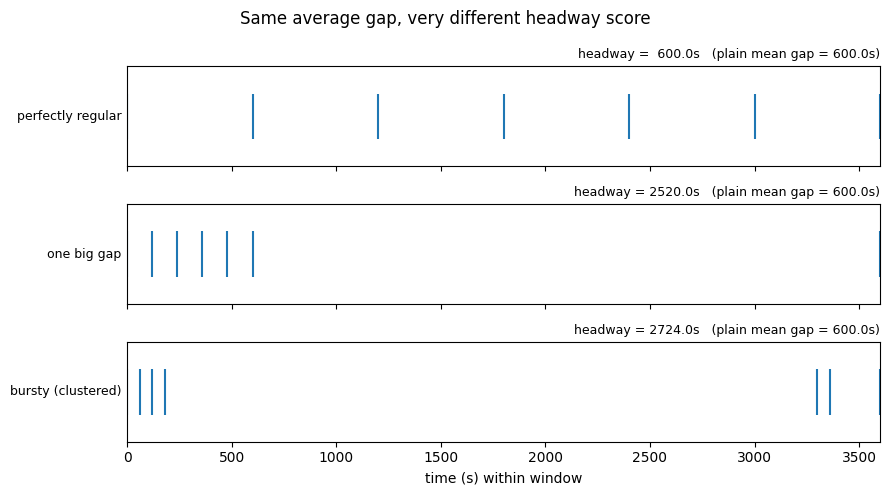

In [6]:
def compute_headway(departures, start, end):
    departures = sorted(departures)
    d = np.array(departures, dtype=float)
    initial_headway = (d[0] - start) + (end - d[-1])
    gaps = np.diff(d)
    return (np.sum(gaps ** 2) + initial_headway ** 2) / (end - start)


start, end = 0, 3600  # a one-hour window, in seconds

# Three schedules with the SAME average gap (one bus every 10 minutes on
# average, 6 departures in the hour) but very different regularity.
schedules = {
    "perfectly regular": [0, 600, 1200, 1800, 2400, 3000, 3600],
    "one big gap": [0, 120, 240, 360, 480, 600, 3600],
    "bursty (clustered)": [0, 60, 120, 180, 3300, 3360, 3600],
}

fig, axes = plt.subplots(len(schedules), 1, figsize=(9, 5), sharex=True)
for ax, (name, deps) in zip(axes, schedules.items()):
    headway = compute_headway(deps, start, end)
    mean_gap = np.mean(np.diff(sorted(deps)))
    ax.eventplot([deps], lineoffsets=0, linelengths=0.8, colors="tab:blue")
    ax.set_xlim(start, end)
    ax.set_yticks([])
    ax.set_ylabel(name, rotation=0, ha="right", va="center", fontsize=9)
    ax.set_title(
        f"headway = {headway:6.1f}s   (plain mean gap = {mean_gap:.1f}s)",
        fontsize=9, loc="right",
    )
axes[-1].set_xlabel("time (s) within window")
fig.suptitle("Same average gap, very different headway score")
plt.tight_layout()
plt.show()


All three schedules above have the *same* average gap between
departures (600s), but the RMS-style `headway` formula scores the uneven
ones much worse than the perfectly regular one -- reflecting that riders
experience a schedule with one huge gap very differently from one with
evenly spaced departures, even if the average is identical.
